# Nested Hierarchical Structure with MQNLI

In this notebook, we use `pyvene` to analyze language models on a complex heirarchical task: multiply-quantified natural language inference (MQNLI). 
We begin by describing the causal structure that generates our data through semantic composition. Then, we analyze whether models that learn this task employ the same compositional structure to solve it.

In [7]:
__author__ = "Amir Zur"

## Set-Up

In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import json 
import random
import numpy as np
from tqdm import tqdm, trange

import torch
from torch.utils.data import DataLoader
from transformers import TrainingArguments, Trainer
from datasets import Dataset

from pyvene import CausalModel
from pyvene import (
    IntervenableModel
)

from pyvene.models.gpt2.modelings_intervenable_gpt2 import create_gpt2_lm

from MQNLI_utils import preprocess, preprocess_counterfactual, compute_metrics, create_counterfactual_dataset, accuracy_metric

In [10]:
import os
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2'

In [11]:
seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

## The MQNLI Task

Multiply-quantified natural language inference (MQNLI) is a variant of natural language inference (NLI) with a highly structured composition. Each datapoint is a pair of sentences, and each label is the logical relation between them (e.g., entailment, reverse entailment, no relation). Crucially, the logical relation can be computed compositionally: first compute the relation between the two sentences' nouns, then their determiners, and then combine these intermediate computations to find the relation between the sentences' noun phrases (NPs). 

In this section, we walk through the high-level causal structure of MQNLI with examples from the MQNLI dataset. We encourage first-time readers to read the original paper, [Geiger, Cases, Karttunen, and Potts (2018)](https://arxiv.org/pdf/1810.13033.pdf), before getting started.

In [12]:
# JSON files generated from adapting MQNLI codebase
# https://github.com/atticusg/MultiplyQuantifiedData

class Hashabledict(dict):
    def __hash__(self):
        return hash(frozenset(self))

with open('tutorial_data/mqnli_q_projectivity.json') as f:
    determiner_signatures = json.load(f)
    determiner_signatures = Hashabledict({
        q1: Hashabledict({
            q2: Hashabledict({
                r1: Hashabledict({
                    r2: determiner_signatures[q1][q2][r1][r2]  
                    for r2 in determiner_signatures[q1][q2][r1]
                })  
                for r1 in determiner_signatures[q1][q2]
            })
            for q2 in determiner_signatures[q1]
        })
        for q1 in determiner_signatures
    })

with open('tutorial_data/mqnli_neg_signature.json') as f:
    negation_signature = Hashabledict(json.load(f))

with open('tutorial_data/mqnli_empty_signature.json') as f:
    emptystring_signature = Hashabledict(json.load(f))

with open('tutorial_data/mqnli_cont_signature.json') as f:
    compose_contradiction_signature = Hashabledict(json.load(f))

with open('tutorial_data/mqnli_neg_cont_signature.json') as f:
    compose_neg_contradiction_signature = Hashabledict(json.load(f))

The format is roughly:

\<linguistic unit>_<position\>  

or

\<linguistic unit>_<premise/hypothesis>_<position\>   

where:

Position
S = subject    
O = object    

Sentence  
P = premise
H = hypothesis

Linguistic units
N   = noun  
Adj = adjective  
Q   = quantifier  
V   = verb  
Adv = adverb  
Neg = negation  
NP  = noun phrase
VP  = verb phrase    
QP  = quantified proposition

In [13]:
parents = {
    "N_P_O": [],
    "N_H_O": [],
    "N_O": ["N_P_O", "N_H_O"],
    "Adj_P_O": [],
    "Adj_H_O": [],
    "Adj_O": ["Adj_P_O", "Adj_H_O"],
    "NP_O": ["Adj_O", "N_O"],
    "Q_P_O": [],
    "Q_H_O": [],
    "Q_O": ["Q_P_O", "Q_H_O"],
    "V_P": [],
    "V_H": [],
    "V": ["V_P", "V_H"],
    "Adv_P": [],
    "Adv_H": [],
    "Adv": ["Adv_P", "Adv_H"],
    "VP": ["Adv", "V"],
    "QP_O": ["Q_O", "NP_O", "VP"],
    "Neg_P": [],
    "Neg_H": [],
    "Neg": ["Neg_P", "Neg_H"],
    "NegP": ["Neg", "QP_O"],
    "N_P_S": [],
    "N_H_S": [],
    "N_S": ["N_P_S", "N_H_S"],
    "Adj_P_S": [],
    "Adj_H_S": [],
    "Adj_S": ["Adj_P_S", "Adj_H_S"],
    "NP_S": ["Adj_S", "N_S"],
    "Q_P_S": [],
    "Q_H_S": [],
    "Q_S": ["Q_P_S", "Q_H_S"],
    "QP_S": ["Q_S", "NP_S", "NegP"]
}

In [14]:
EMPTY = ""
IND = "independence"
EQV = "equivalence"
ENT = "entails"
REV = "reverse entails"
CON = "contradiction"
ALT = "alternation"
COV = "cover"
# all possible relation values from the original paper 
# (https://arxiv.org/pdf/1810.13033.pdf)
RELATIONS = [IND, EQV, ENT, REV, CON, ALT, COV]

Q_VALUES = [
    determiner_signatures[q1][q2]
    for q1 in determiner_signatures for q2 in determiner_signatures[q1]
]

values = {
    "N_P_O": ["tree", "rock"],
    "N_H_O": ["tree", "rock"],
    "N_O": [EQV, IND],
    "Adj_P_O": ["happy", "sad", EMPTY],
    "Adj_H_O": ["happy", "sad", EMPTY],
    "Adj_O": [EQV, IND, ENT, REV],
    "NP_O": [EQV, IND, ENT, REV],
    "Q_P_O": ["some", "every"],
    "Q_H_O": ["some", "every"],
    "Q_O": Q_VALUES,
    "V_P": ["climbed", "threw"],
    "V_H": ["climbed", "threw"],
    "V": [EQV, IND],
    "Adv_P": ["energetically", "joyfully", EMPTY],
    "Adv_H": ["energetically", "joyfully", EMPTY],
    "Adv": [EQV, IND, ENT, REV],
    "VP": [EQV, IND, ENT, REV],
    "QP_O": [EQV, IND, ENT, REV],
    "Neg_P": ["not", EMPTY],
    "Neg_H": ["not", EMPTY],
    "Neg": [
        negation_signature, 
        emptystring_signature, 
        compose_contradiction_signature, 
        compose_neg_contradiction_signature
    ],
    "NegP": RELATIONS,
    "N_P_S": ["child", "dog"],
    "N_H_S": ["child", "dog"],
    "N_S": [EQV, IND],
    "Adj_P_S": ["little", "cute", EMPTY],
    "Adj_H_S": ["little", "cute", EMPTY],
    "Adj_S": [EQV, IND, ENT, REV],
    "NP_S": [EQV, IND, ENT, REV],
    "Q_P_S": ["some", "every"],
    "Q_H_S": ["some", "every"],
    "Q_S": Q_VALUES,
    "QP_S": RELATIONS
}

In [15]:
# adapted from original code for MQNLI:
# https://github.com/atticusg/MultiplyQuantifiedData/blob/master/natural_logic_model.py

def adj_merge(adj_p, adj_h):
    if adj_p == adj_h:
        return EQV
    if adj_p == EMPTY:
        return REV
    if adj_h == EMPTY:
        return ENT
    return IND

adv_merge = adj_merge

def noun_phrase(adj, noun):
    #merges a noun relation with an adjective relation
    #or a verb relation with an adverb relation
    # makes sense: if the objects are the same, then adjective's relation holds
    # otherwise, they're independent
    if noun == EQV:
        return adj
    return IND

verb_phrase = noun_phrase

def negation_merge(neg_p, neg_h):
    #merges negation
    if neg_p == neg_h and neg_p == EMPTY:
        return Hashabledict(emptystring_signature)
    if neg_p == neg_h and neg_p != EMPTY:
        return Hashabledict(negation_signature)
    if neg_p == EMPTY:
        return Hashabledict(compose_contradiction_signature)
    if neg_p != EMPTY:
        return Hashabledict(compose_neg_contradiction_signature)

negation_phrase = lambda neg, qp: neg[qp]

noun_merge = lambda n_p, n_h: EQV if n_p == n_h else IND
verb_merge = noun_merge

quantifier_merge = lambda q_p, q_h: determiner_signatures[q_p][q_h]

quantifier_phrase = lambda q, np, vp: q[np][vp]

functions = {
    "N_P_O": lambda: "tree",
    "N_H_O": lambda: "tree",
    "N_O": noun_merge,
    "Adj_P_O": lambda: "happy",
    "Adj_H_O": lambda: "happy",
    "Adj_O": adj_merge,
    "NP_O": noun_phrase,
    "Q_P_O": lambda: "some",
    "Q_H_O": lambda: "some",
    "Q_O": quantifier_merge,
    "V_P": lambda: "climbed",
    "V_H": lambda: "climbed",
    "V": verb_merge,
    "Adv_P": lambda: "energetically",
    "Adv_H": lambda: "energetically",
    "Adv": adv_merge,
    "VP": verb_phrase,
    "QP_O": quantifier_phrase,
    "Neg_P": lambda: "not",
    "Neg_H": lambda: "not",
    "Neg": negation_merge,
    "NegP": negation_phrase,
    "N_P_S": lambda: "dog",
    "N_H_S": lambda: "dog",
    "N_S": noun_merge,
    "Adj_P_S": lambda: "cute",
    "Adj_H_S": lambda: "cute",
    "Adj_S": adj_merge,
    "NP_S": noun_phrase,
    "Q_P_S": lambda: "some",
    "Q_H_S": lambda: "some",
    "Q_S": quantifier_merge,
    "QP_S": quantifier_phrase
}

In [16]:
# coordinates to display the MQNLI tree
pos = {
    "N_P_O": (32, 0.3),
    "N_H_O": (30, 0.7),
    "N_O": (31, 1.3),
    "Adj_P_O": (28, 0),
    "Adj_H_O": (26, 0.5),
    "Adj_O": (27, 1),
    "NP_O": (29, 2),
    "Q_P_O": (24, 1.3),
    "Q_H_O": (22, 1.7),
    "Q_O": (23, 2.5),
    "V_P": (21, 0),
    "V_H": (19, 0.5),
    "V": (20, 1),
    "Adv_P": (17, -0.3),
    "Adv_H": (15, 0.2),
    "Adv": (16, 0.7),
    "VP": (18, 2),
    "QP_O": (25, 3),
    "Neg_P": (13, 2.5),
    "Neg_H": (11, 3),
    "Neg": (12, 3.5),
    "NegP": (14, 4),
    "N_P_S": (9, 2.2),
    "N_H_S": (7, 2.8),
    "N_S": (8, 3.3),
    "Adj_P_S": (5, 1.5),
    "Adj_H_S": (3, 2),
    "Adj_S": (4, 2.5),
    "NP_S": (6, 4.3),
    "Q_P_S": (2, 3.2),
    "Q_H_S": (0, 3.5),
    "Q_S": (1, 4),
    "QP_S": (10, 5)
}

In [17]:
variables = list(parents.keys())  # pretty sure this preserves order?

In [18]:
mqlni_model = CausalModel(variables, values, parents, functions, pos=pos)

We begin by visualizing the high-level structure of the MQNLI task. All leaf nodes consist of text entries (e.g., Adj_P_O might be "fun", N_H_O might be "child"), with one copy corresponding to the premise sentence (P) and the other corresponding to the hypothesis (H). All other nodes take on relation values (e.g., entailment, reverse entailment, no relation), or mappings between relations (e.g., (entailment, entailment) --> no entailment).

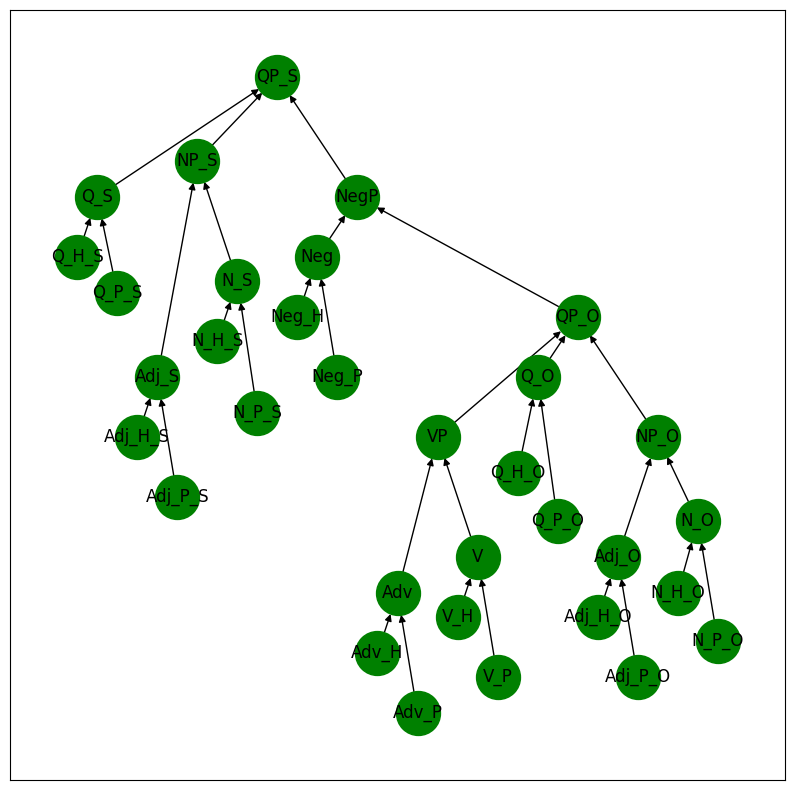

In [19]:
mqlni_model.print_structure()

### Example MQNLI Input

Here we walk through an example MQNLI input, presented below.
```json
Premise: Every dog climbed some tree.
Hypothesis: Some dog did not climb some tree.
```

The output for this sentence pair is `contradiction`, because the premise entails that there cannot be a dog who climbed no tree. 

In [20]:
inputs = {
    # premise
    "Q_P_S": "every",
    "Adj_P_S": EMPTY,
    "N_P_S": "dog",
    "Neg_P": EMPTY,
    "Adv_P": EMPTY,
    "V_P": "climbed",
    "Q_P_O": "some",
    "Adj_P_O": EMPTY,
    "N_P_O": "tree",
    # hypothesis
    "Q_H_S": "some",
    "Adj_H_S": EMPTY,
    "N_H_S": "dog",
    "Neg_H": "not",
    "Adv_H": EMPTY,
    "V_H": "climbed",
    "Q_H_O": "some",
    "Adj_H_O": EMPTY,
    "N_H_O": "tree"
}

setting = mqlni_model.run_forward(inputs)

In [21]:
from MQNLI_utils import print_premise, print_hypothesis

print_premise(setting)
print_hypothesis(setting)

print(setting["QP_S"]) # the output is in the root node, QP_S

every  dog   climbed some  tree
some  dog not  climbed some  tree
contradiction


We display the structure of the MQNLI example below. Note that the intermediate relation values compose with each other to produce the final output. For instance, since `N_O` and `Adj_O` both take on the value `equivalence`, then `NP_O` is also an equivalence relation.

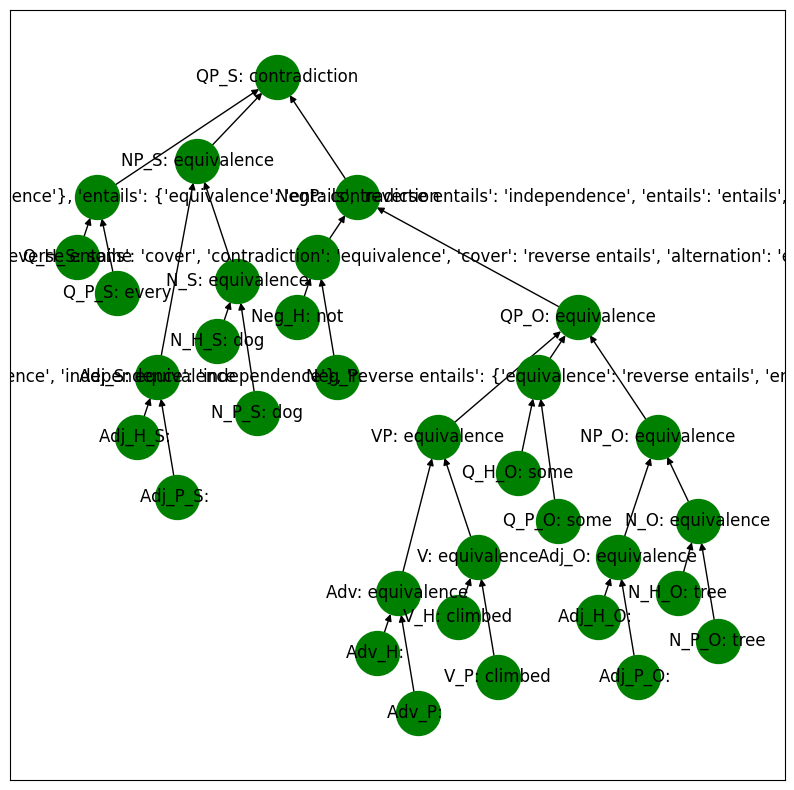

In [22]:
display = {v: not isinstance(values[v][0], dict) for v in variables}
mqlni_model.print_setting(setting)

### MQNLI with an Intervention

Below is a run of the MQNLI logic model where we intervene on the object quantifier (`QP_O`) and swap its relation value from `equivalence` to `contradiction`. Note that this changes the final output from `contradiction` to `entailment`.

In [ ]:
intervention = {**inputs, 'QP_O': 'contradiction'}
setting = mqlni_model.run_forward(intervention)
print_premise(setting)
print_hypothesis(setting)
print(setting["QP_S"])

mqlni_model.print_setting(setting)

## Training a Model on MQNLI

In this section, we train a language model (GPT-2) on the MQNLI task. Importantly, we do not need to access the original MQNLI dataset to do this -- having set up our causal model earlier in this notebook, we can generate datapoints by sampling from it directly! 

See `MQNLI_train_model.py`

## Interpreting Our Model

In this final section, we use distributed alignment search DAS from [Geiger*, Wu*, Potts, Icard, and Goodman (2024)](https://arxiv.org/pdf/2303.02536.pdf) to find an alignment between the high-level causal structure of MQNLI and our low-level language model trained on the MQNLI dataset.

In this section, we won't search for an alignment over the entire causal structure. Instead, we will search for an alignment between the low-level model representations and the `NegP` token. Efficiently searching for a full alignment over a complex, nested causal structure is an open problem that is worth pursuing! 

Train DAS to find an alignment between our high-level causal model and the language model trained on MQNLI. See `MQNLI_train_das.py`

### Evaluate DAS Alignment

Lastly, we evaluate the accuracy of the alignment found by DAS. 

In [ ]:
TRAIN_DIR = 'mqnli_factual'
DAS_SUBSPACE_PARTITION = 128
DAS_LAYER = 10
DAS_DIR = 'mqnli_das_{}_{}'.format(DAS_LAYER, DAS_SUBSPACE_PARTITION)

_, tokenizer, model = create_gpt2_lm(name=TRAIN_DIR)
intervenable = IntervenableModel.load(DAS_DIR, model)

First, we evaluate the model's performance on the MQNLI factual task. As before, we expect our model to complete this task with nearly perfect accuracy.

In [ ]:
examples = mqlni_model.generate_factual_dataset(
    100,
    sampler=mqlni_model.sample_input_tree_balanced,
    return_tensors=False
)
X = [example['input_ids'] for example in examples]
y = [example['labels'] for example in examples]

test_factual_dataset = preprocess(X, y, tokenizer)

In [ ]:
test_factual_ds = Dataset.from_dict(test_factual_dataset)

batch_size = 8

training_args = TrainingArguments(
    output_dir="test_mqnli_trainer",
    per_device_eval_batch_size=batch_size,
    report_to="none",
    # use_cpu=True,
)

trainer = Trainer(
    model=intervenable.model,
    args=training_args,
    compute_metrics=accuracy_metric
)

In [ ]:
trainer.evaluate(test_factual_ds)

### IIA

Next, we evaluate the DAS alignment on a newly-sampled counterfactual dataset. If our alignment generalizes, then we should expect a high interchange intervention accuracy (IIA) on the counterfactual dataset. We compute IIA by comparing the model's output with an interchange-intervention to the causal model's output with that same intervention applied to its high-level variables (i.e., we verify that an intervention changes the model's output in the direction that our causal model predicts). 

In [ ]:
dataset = create_counterfactual_dataset(mqlni_model, 1000, 1)

In [ ]:
test_cf_dataset = preprocess_counterfactual(dataset, tokenizer)

In [ ]:
intervenable.set_device('cuda')
print("intervention trainable parameters: ", intervenable.count_parameters())

base_labels = None
counterfactual_labels = None
counterfactual_preds = None

batch_size = 8
MAX_LENGTH = 64
with torch.no_grad():
    for batch in tqdm(DataLoader(
        test_cf_dataset,
        batch_size=batch_size,
        drop_last=True
    )):
        inputs = {k: v.to(intervenable.get_device()) for k, v in batch['input'].items()}
        sources = [{k: v.to(intervenable.get_device()) for k, v in s.items()} for s in batch['source']]
        _, counterfactual_outputs = intervenable(
            inputs,
            sources,
            {"sources->base": ([[[MAX_LENGTH - 2]] * batch_size], [[[MAX_LENGTH - 2]] * batch_size])},
            subspaces=[[[0]] * batch_size],
        )

        if base_labels is None:
            counterfactual_preds = counterfactual_outputs.logits.argmax(-1).clone().detach()
            counterfactual_labels = batch['label']
        else:
            counterfactual_preds = torch.cat((counterfactual_preds, counterfactual_outputs.logits.argmax(-1).clone().detach()))
            counterfactual_labels = torch.cat((counterfactual_labels, batch['label']))

In [ ]:
{
    'counterfactual_accuracy': compute_metrics(counterfactual_preds, counterfactual_labels)['accuracy']
}

### Layer and subspace dimension sweeps

In [3]:
# temporary - remove later

%load_ext autoreload
%autoreload 2
import random
import numpy as np
from tqdm import tqdm, trange
import torch
from torch.utils.data import DataLoader
from transformers import TrainingArguments, Trainer
from datasets import Dataset
from pyvene import (
    IntervenableModel
)
from pyvene.models.gpt2.modelings_intervenable_gpt2 import create_gpt2_lm
from MQNLI_utils import preprocess, preprocess_counterfactual, compute_metrics, create_counterfactual_dataset, accuracy_metric
import os
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2'
seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

from MQNLI_utils import create_causal_model
mqlni_model = create_causal_model()

nnsight is not detected. Please install via 'pip install nnsight' for nnsight backend.


In [4]:
TRAIN_DIR = 'mqnli_factual'
dataset = create_counterfactual_dataset(mqlni_model, 1000, 1)
examples = mqlni_model.generate_factual_dataset(
    100,
    sampler=mqlni_model.sample_input_tree_balanced,
    return_tensors=False
)
X = [example['input_ids'] for example in examples]
y = [example['labels'] for example in examples]

counterfactual_accuracy = {
    # layer sweeps
    "0_128": None,
    "2_128": None,
    "4_128": None,
    "6_128": None,
    "8_128": None,
    "10_128": None,
    # subspace dim sweeps
    "10_4": None,
    "10_8": None,
    "10_16": None,
    "10_32": None,
    "10_64": None,
    "10_128": None,
}
factual_accuracy = {k: None for k in counterfactual_accuracy.keys()}

for i in [0, 2, 4, 6, 8, 10]:
    for s in [4, 8, 16, 32, 64, 128]:
        if "{}_{}".format(i, s) not in counterfactual_accuracy:
            continue

        print("Evaluating model with intervention on layer {}, subspace dim {}...".format(i, s))

        # load model
        DAS_DIR = 'mqnli_das_{}_{}'.format(str(i), str(s))

        # temporary - if DAS_DIR does not exist on disk, print and continue for now
        if not os.path.exists(DAS_DIR):
            print("DAS_DIR {} does not exist, skipping...".format(DAS_DIR))
            continue

        _, tokenizer, model = create_gpt2_lm(name=TRAIN_DIR)
        intervenable = IntervenableModel.load(DAS_DIR, model)

        ######### factual evaluation #########

        test_factual_dataset = preprocess(X, y, tokenizer)
        test_factual_ds = Dataset.from_dict(test_factual_dataset)

        batch_size = 8
        training_args = TrainingArguments(
            output_dir="test_mqnli_trainer",
            per_device_eval_batch_size=batch_size,
            report_to="none",
            # use_cpu=True,
        )
        trainer = Trainer(
            model=intervenable.model,
            args=training_args,
            compute_metrics=accuracy_metric
        )
        factual_accuracy["{}_{}".format(i, s)] = trainer.evaluate(test_factual_ds)["eval_accuracy"]

        ######### IIA / counterfactual evaluation #########

        test_cf_dataset = preprocess_counterfactual(dataset, tokenizer)
        intervenable.set_device('cuda')

        base_labels = None
        counterfactual_labels = None
        counterfactual_preds = None

        batch_size = 8
        MAX_LENGTH = 64
        with torch.no_grad():
            for batch in tqdm(DataLoader(
                test_cf_dataset,
                batch_size=batch_size,
                drop_last=True
            )):
                inputs = {k: v.to(intervenable.get_device()) for k, v in batch['input'].items()}
                sources = [{k: v.to(intervenable.get_device()) for k, v in s.items()} for s in batch['source']]
                _, counterfactual_outputs = intervenable(
                    inputs,
                    sources,
                    {"sources->base": ([[[MAX_LENGTH - 2]] * batch_size], [[[MAX_LENGTH - 2]] * batch_size])},
                    subspaces=[[[0]] * batch_size],
                )

                if base_labels is None:
                    counterfactual_preds = counterfactual_outputs.logits.argmax(-1).clone().detach()
                    counterfactual_labels = batch['label']
                else:
                    counterfactual_preds = torch.cat((counterfactual_preds, counterfactual_outputs.logits.argmax(-1).clone().detach()))
                    counterfactual_labels = torch.cat((counterfactual_labels, batch['label']))
                    
        counterfactual_accuracy["{}_{}".format(i, s)] = compute_metrics(counterfactual_preds, counterfactual_labels)['accuracy']

Evaluating model with intervention on layer 0, subspace dim 128...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

loaded model


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Training Loss,Validation Loss,Step,Accuracy
No log,2.061888,0,0.590000


...

Evaluating model with intervention on layer 10, subspace dim 128...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

loaded model


Training Loss,Validation Loss,Step,Accuracy
No log,2.061888,0,0.590000


100%|██████████| 125/125 [00:02<00:00, 43.97it/s]


In [5]:
counterfactual_accuracy, factual_accuracy

({'0_128': 0.25,
  '2_128': 0.25,
  '4_128': 0.25,
  '6_128': 0.25,
  '8_128': 0.375,
  '10_128': 0.5,
  '10_4': 0.125,
  '10_8': 0.25,
  '10_16': 0.375,
  '10_32': 0.5,
  '10_64': 0.25},
 {'0_128': 0.59,
  '2_128': 0.59,
  '4_128': 0.59,
  '6_128': 0.59,
  '8_128': 0.59,
  '10_128': 0.59,
  '10_4': 0.59,
  '10_8': 0.59,
  '10_16': 0.59,
  '10_32': 0.59,
  '10_64': 0.59})

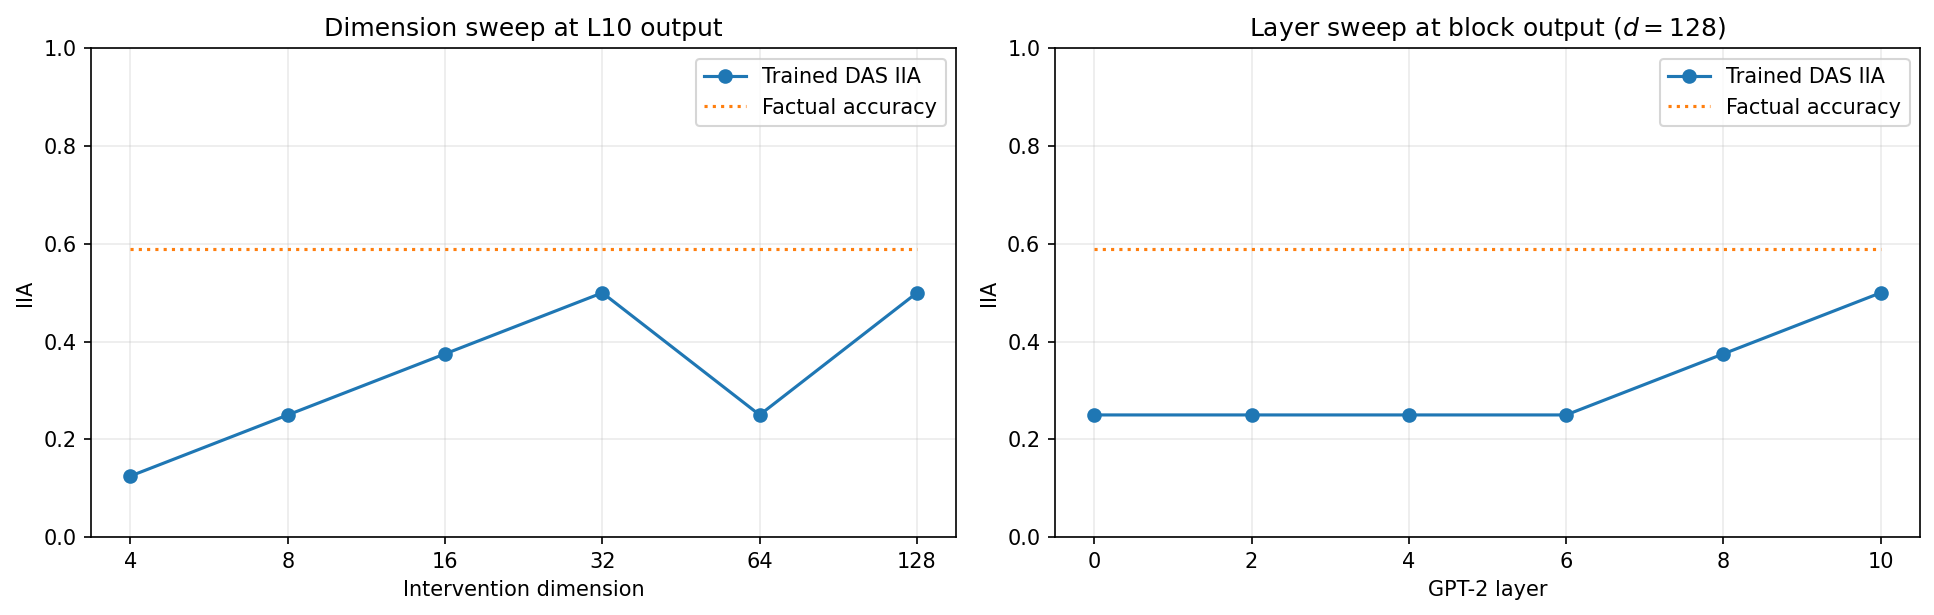

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# counterfactual_accuracy = {'0_128': 0.25,
#   '2_128': 0.25,
#   '4_128': 0.25,
#   '6_128': 0.25,
#   '8_128': 0.375,
#   '10_128': 0.5,
#   '10_4': 0.125,
#   '10_8': 0.25,
#   '10_16': 0.375,
#   '10_32': 0.5,
#   '10_64': 0.25,
# }

# factual_accuracy = {'0_128': 0.59,
#   '2_128': 0.59,
#   '4_128': 0.59,
#   '6_128': 0.59,
#   '8_128': 0.59,
#   '10_128': 0.59,
#   '10_4': 0.59,
#   '10_8': 0.59,
#   '10_16': 0.59,
#   '10_32': 0.59,
#   '10_64': 0.59,
# }

def val(d, k):
    return np.nan if d[k] is None else d[k]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), dpi=150)

# left: dimension sweep at layer 10
dims = [4, 8, 16, 32, 64, 128]
dim_keys = [f"10_{d}" for d in dims]

axes[0].plot(
    dims,
    [val(counterfactual_accuracy, k) for k in dim_keys],
    marker="o",
    label="Trained DAS IIA",
)
axes[0].plot(
    dims,
    [val(factual_accuracy, k) for k in dim_keys],
    linestyle=":",
    label="Factual accuracy",
)
axes[0].set_title("Dimension sweep at L10 output")
axes[0].set_xlabel("Intervention dimension")
axes[0].set_ylabel("IIA")
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(dims)
axes[0].set_xticklabels(dims)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.25)
axes[0].legend()

# right: layer sweep at dimension 128
layers = [0, 2, 4, 6, 8, 10]
layer_keys = [f"{l}_128" for l in layers]

axes[1].plot(
    layers,
    [val(counterfactual_accuracy, k) for k in layer_keys],
    marker="o",
    label="Trained DAS IIA",
)
axes[1].plot(
    layers,
    [val(factual_accuracy, k) for k in layer_keys],
    linestyle=":",
    label="Factual accuracy",
)
axes[1].set_title("Layer sweep at block output ($d=128$)")
axes[1].set_xlabel("GPT-2 layer")
axes[1].set_ylabel("Accuracy / IIA")
axes[1].set_xticks(layers)
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()